# Post Race Evaluation

Input
- constructor and driver prediction tables
- hist driver and constructor points
- team config table (not yet created)


Processing
- log prediction absolute errors
- log best team (using teamOptimizer notebook/script)

Output
- show graph of trends of best team as well as my error rate

### Libraries

In [311]:
from pathlib import Path
import pandas as pd
import numpy as np
import os

import sys
sys.path.append("/Users/jackguptill/Library/CloudStorage/OneDrive-Personal/Code/F1FantasyProject")

import teamOptimizer as to

In [312]:
import os
os.getcwd()

'/Users/jackguptill/Library/CloudStorage/OneDrive-Personal/Code/F1FantasyProject/notebooks/evaluation'

In [313]:
working_directory = Path.cwd().parent.parent
print(working_directory)

/Users/jackguptill/Library/CloudStorage/OneDrive-Personal/Code/F1FantasyProject


### Data Import

In [314]:
driver_path = working_directory / "data" / "predictions" / "drivers" / "driver_predictions_2026.csv"
con_path = working_directory / "data" / "predictions" / "constructors" / "constructor_preds_2026.csv"

driver_race_results_path = working_directory / "data" / "clean" / "driver_points.csv"
constructor_race_results_path = working_directory / "data" / "clean" / "constructor_points.csv"

team_path = working_directory / "data" / "myTeam" / "teamConfig.csv"

#prediction tables
driver_preds = pd.read_csv(driver_path)
constructor_preds = pd.read_csv(con_path)

#results tables
driver_race_results = pd.read_csv(driver_race_results_path).drop(columns=['Unnamed: 0'])
con_race_results = pd.read_csv(constructor_race_results_path).drop(columns=['Unnamed: 0'])

#weekly config table
team_config = pd.read_csv(team_path)

## Data Clean

- joining and cleaning tables to get a single table that has our prediction performance
- will eventually use this to create graphs on how we are doing

### Creating a "Log" of the performance of predictions and results
- will contain features such as absolute error rate

In [315]:
constructor_preds["asset_name"] = constructor_preds["constructor"]
con_race_results["asset_name"] = con_race_results["constructor"]
con_race_results = con_race_results.drop(columns=["constructor"])

In [316]:
driver_preds["asset_name"] = driver_preds["driver"]
driver_race_results["asset_name"] = driver_race_results["driver"]
driver_preds = driver_preds.drop(columns=["driver"])

In [317]:
#name change to be in sync with preds
driver_race_results["race_num"] = driver_race_results["race"]
con_race_results["race_num"] = con_race_results["race"]

driver_race_results = driver_race_results.drop(columns=["race"])
con_race_results = con_race_results.drop(columns=["race"])

In [318]:
constructor_preds["asset_type"] = "constructor"

In [319]:
driver_preds["asset_type"] = "driver"

In [320]:
predictions = pd.concat([constructor_preds, driver_preds], axis=0, ignore_index = True)
predictions["asset_name"] = predictions['asset_name'].str.upper()
predictions = predictions[["year", "race_num", "asset_name", "price", "predicted_points", "asset_type"]]
predictions

,year,race_num,asset_name,price,predicted_points,asset_type
0,2026,1,MCL,28.9,53.242756,constructor
1,2026,1,MER,29.3,51.584534,constructor
2,2026,1,RBR,28.2,48.359364,constructor
3,2026,1,FER,23.3,40.582527,constructor
4,2026,1,RB,6.3,26.878194,constructor
...,...,...,...,...,...,...
61,2026,2,COL,6.4,6.220915,driver
62,2026,2,LAW,6.3,1.715410,driver
63,2026,2,HUL,6.2,3.487286,driver
64,2026,2,PER,5.8,5.127959,driver


## Left Join Results to the predictions

In [321]:
driver_race_results = driver_race_results[['year', 'race_num', 'asset_name', 'points']]
con_race_results = con_race_results[["year", "race_num", "asset_name", "points"]]
predictions = predictions.merge(driver_race_results, how = "left", on=["year", "race_num", "asset_name"])
predictions = predictions.merge(con_race_results, how = "left", on=["year", "race_num", "asset_name"])

predictions["points"] = predictions["points_x"].combine_first(predictions["points_y"])
predictions = predictions.drop(columns=["points_x", "points_y"])
predictions = predictions.drop_duplicates(subset=["year", "race_num", "asset_name"])
predictions

,year,race_num,asset_name,price,predicted_points,asset_type,points
0,2026,1,MCL,28.9,53.242756,constructor,19.0
1,2026,1,MER,29.3,51.584534,constructor,96.0
2,2026,1,RBR,28.2,48.359364,constructor,42.0
3,2026,1,FER,23.3,40.582527,constructor,69.0
4,2026,1,RB,6.3,26.878194,constructor,35.0
...,...,...,...,...,...,...,...
61,2026,2,COL,6.4,6.220915,driver,18.0
62,2026,2,LAW,6.3,1.715410,driver,35.0
63,2026,2,HUL,6.2,3.487286,driver,7.0
64,2026,2,PER,5.8,5.127959,driver,20.0


#### creating a clean copy for visualizations and metrics

In [322]:
performance = predictions.copy()

## Getting Our Overall Mean Absolute Error of Our Predictions

In [323]:
year = 2026
race = 2
last_week_performance = performance[(performance['year'] == year) & (performance['race_num'] == race)]

In [324]:
last_week_performance["absolute_error"] = abs(last_week_performance["points"] - last_week_performance['predicted_points'])


/var/folders/wb/stch18dn2z1gw9s72md26f740000gn/T/ipykernel_6429/3448781110.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_week_performance["absolute_error"] = abs(last_week_performance["points"] - last_week_performance['predicted_points'])


In [325]:
last_week_performance = last_week_performance.sort_values(["asset_type", "absolute_error"], ascending=[False, False])
last_week_performance

,year,race_num,asset_name,price,predicted_points,asset_type,points,absolute_error
48,2026,2,ANT,23.5,11.763255,driver,68.0,56.236745
46,2026,2,NOR,27.1,24.957439,driver,-10.0,34.957439
62,2026,2,LAW,6.3,1.715410,driver,35.0,33.284590
49,2026,2,LEC,23.1,22.071544,driver,51.0,28.928456
47,2026,2,PIA,25.2,20.350181,driver,-7.0,27.350181
44,2026,2,VER,28.0,41.015713,driver,14.0,27.015713
50,2026,2,HAM,22.6,21.341708,driver,48.0,26.658292
53,2026,2,SAI,11.6,2.377343,driver,28.0,25.622657
56,2026,2,BEA,8.0,9.973023,driver,34.0,24.026977
58,2026,2,STR,7.4,9.919571,driver,-14.0,23.919571


In [326]:
np.mean(last_week_performance["absolute_error"])

np.float64(22.715694502777712)

In [327]:
#FIXME: make a current week or past week MAE

### Output Actual Error Rates for the Week

## What was the Optimal Team Last Week?

#### re-reading in a clean version of the hist tables for this

In [328]:
driver_roster_path = working_directory / "data" / "clean" / "driver_roster.csv"
last_week_construcor_pricing_path = working_directory / "data" / "clean" / "constructor_price.csv"
last_week_driver_pricing_path = working_directory / "data" / "clean" / "driver_price.csv"


last_week_drivers = pd.read_csv(driver_race_results_path).drop(columns=['Unnamed: 0'])
last_week_constructors = pd.read_csv(constructor_race_results_path).drop(columns=['Unnamed: 0'])
last_week_driver_pricing = pd.read_csv(last_week_driver_pricing_path).drop(columns=['Unnamed: 0'])
last_week_construcor_pricing = pd.read_csv(last_week_construcor_pricing_path).drop(columns=['Unnamed: 0'])
last_week_driver_roster = pd.read_csv(driver_roster_path).drop(columns=['Unnamed: 0'])

In [329]:
latest_row = last_week_drivers.sort_values(["year", "race"]).iloc[-1]
year = latest_row["year"]
race = latest_row["race"]
print(year, race)

2026 2


#### Filtering to latest week

In [330]:
last_week_drivers = last_week_drivers[(last_week_drivers["year"] == year) & (last_week_drivers["race"] == race)].reset_index(drop=True)
last_week_constructors = last_week_constructors[(last_week_constructors["year"] == year) & (last_week_constructors["race"] == race)].reset_index(drop=True)
last_week_driver_roster = last_week_driver_roster[(last_week_driver_roster["year"] == year) & (last_week_driver_roster["race"] == race)].reset_index(drop=True)
last_week_driver_pricing = last_week_driver_pricing[(last_week_driver_pricing["year"] == year) & (last_week_driver_pricing["race"] == race)].reset_index(drop=True)
last_week_construcor_pricing = last_week_construcor_pricing[(last_week_construcor_pricing["year"] == year) & (last_week_construcor_pricing["race"] == race)].reset_index(drop=True)



In [331]:
last_week_construcor_pricing.head()

,constructor,race,price,year,race_name,start_date,location,country_code,meeting_key,month,start_epoch
0,MER,2,29.6,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000
1,MCL,2,28.8,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000
2,RBR,2,28.5,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000
3,FER,2,23.6,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000
4,ALP,2,13.1,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000


In [332]:
last_week_driver_pricing = last_week_driver_pricing[["year", "race", "driver", "price"]]
last_week_constructor_pricing = last_week_construcor_pricing[["year", "race", "constructor", "price"]]

In [333]:
#driver merges
last_week_drivers = last_week_drivers.merge(last_week_driver_roster, on=["year", "race", "driver"], how="left")
last_week_drivers = last_week_drivers.merge(last_week_driver_pricing, on=["year", "race", "driver"], how="left")


last_week_drivers

,driver,race,points,year,race_name,start_date,location,country_code,meeting_key,month,start_epoch,constructor,price
0,VER,2,14.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,RBR,28.0
1,RUS,2,45.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,MER,27.7
2,NOR,2,-10.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,MCL,27.1
3,PIA,2,-7.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,MCL,25.2
4,ANT,2,68.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,MER,23.5
5,LEC,2,51.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,FER,23.1
6,HAM,2,48.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,FER,22.6
7,HAD,2,19.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,RBR,14.5
8,GAS,2,20.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,ALP,12.2
9,SAI,2,28.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,WIL,11.6


In [334]:
#constructor merges
last_week_constructors = last_week_constructors.merge(last_week_constructor_pricing, on=["year", "race", "constructor"], how="left")

In [335]:
#last week driver table build
#cols needed: year, race_num, driver, price, constructor, points
#renaming as needed
last_week_drivers = last_week_drivers.rename(columns={'race':'race_num'})
last_week_drivers = last_week_drivers[["year", "race_num", "driver", "price", "points", "constructor"]]


In [336]:
last_week_constructors

,constructor,race,points,year,race_name,start_date,location,country_code,meeting_key,month,start_epoch,price
0,MER,2,115.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,29.6
1,MCL,2,-7.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,28.8
2,RBR,2,45.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,28.5
3,FER,2,119.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,23.6
4,ALP,2,45.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,13.1
5,WIL,2,22.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,12.6
6,AMR,2,-20.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,9.7
7,HAS,2,65.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,8.0
8,AUD,2,-4.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,6.0
9,RB,2,50.0,2026,Chinese Grand Prix,2026-03-15 07:00:00+00:00,Shanghai,CHN,1280,3,1773558000,6.9


In [337]:
#last week constructor table build
#cols needed: year, race_num, constructor, price, points
last_week_constructors = last_week_constructors.rename(columns={'race':'race_num'})
last_week_constructors = last_week_constructors[["year", "race_num", "constructor", "price", "points"]]

In [338]:
last_week_lineup = {
    "drivers": {"VER", "LEC", "HUL", "COL", "LAW"}, 
    "constructors": {"FER", "RB"}
}

In [339]:
drivers_sel, cons_sel, summary = to.optimize_team(
    budget=100.9,
    drivers=last_week_drivers,
    cons=last_week_constructors,
    last_week_lineup = last_week_lineup, 
    free_transfers_avail = 2,
    points_col="points",
    n_drivers=5,
    n_constructors=2,
    max_drivers_per_team=2,
    use_drs=True,
    drs_multiplier=2.0,
    solver_msg=False,
    require_driver_from_each_constructor=False,
    min_drivers_per_selected_constructor=1
)

print(summary)
display(drivers_sel)
display(cons_sel)

{'status': 1, 'budget': 100.9, 'points_column_used': 'points', 'total_price': 98.9, 'gross_points': 458.0, 'total_transfers': 3, 'free_transfers_avail': 2, 'paid_transfers': 1, 'transfer_penalty': 10, 'net_points': 448.0, 'drs_driver': 'ANT'}


,year,race_num,driver,price,points,constructor,team_key,driver_key
0,2026,2,ANT,23.5,68.0,MER,MER,ANT
1,2026,2,LEC,23.1,51.0,FER,FER,LEC
2,2026,2,LAW,6.3,35.0,RB,RB,LAW
3,2026,2,BEA,8.0,34.0,HAS,HAS,BEA
4,2026,2,COL,6.4,18.0,ALP,ALP,COL


,year,race_num,constructor,price,points,team_key
0,2026,2,FER,23.6,119.0,FER
1,2026,2,HAS,8.0,65.0,HAS


### Log the Best Driver Config

In [340]:
drivers_sel = drivers_sel.rename(columns={"driver": "asset_name"})
cons_sel = cons_sel.rename(columns={"constructor": "asset_name"})

drivers_sel["asset_type"] = "driver"
cons_sel["asset_type"] = "constructor"

In [341]:
cols = [
    "year",
    "race_num",
    "asset_name",
    "asset_type",
    "price",
    "points",
    "team_key"
]

drivers_sel = drivers_sel[cols]
cons_sel = cons_sel[cols]

In [342]:
best_team = pd.concat([drivers_sel, cons_sel], ignore_index=True)

In [343]:
best_team["is_drs"] = np.where(
    best_team["asset_name"] == summary["drs_driver"],
    "yes",
    "no"
)

In [344]:
best_team.head()

,year,race_num,asset_name,asset_type,price,points,team_key,is_drs
0,2026,2,ANT,driver,23.5,68.0,MER,yes
1,2026,2,LEC,driver,23.1,51.0,FER,no
2,2026,2,LAW,driver,6.3,35.0,RB,no
3,2026,2,BEA,driver,8.0,34.0,HAS,no
4,2026,2,COL,driver,6.4,18.0,ALP,no


### append data to best_team log

#### read in old best_team

In [345]:
best_team_file_path = working_directory /'data' / 'myTeam' / 'bestTeam.csv'
old_best_team = pd.read_csv(best_team_file_path)

In [346]:
old_best_team.head()

,Unnamed: 0,year,race_num,asset_name,asset_type,price,points,team_key,is_drs
0,0,2026,1,VER,driver,27.7,50.0,RBR,yes
1,1,2026,1,BEA,driver,7.4,20.0,HAS,no
2,2,2026,1,LIN,driver,6.2,15.0,RB,no
3,3,2026,1,BOR,driver,6.4,13.0,AUD,no
4,4,2026,1,GAS,driver,12.0,11.0,ALP,no


In [347]:
best_team.columns

Index(['year', 'race_num', 'asset_name', 'asset_type', 'price', 'points',
       'team_key', 'is_drs'],
      dtype='object')

In [348]:
best_team["asset_type"] = np.where(
    best_team["asset_name"] != best_team["team_key"],
    "driver",
    "constructor"
)

In [349]:
old_best_team = old_best_team.drop(columns=["Unnamed: 0"], errors="ignore")
best_team = best_team.drop(columns=["Unnamed: 0"], errors="ignore")
concat_best_team = pd.concat([old_best_team, best_team], ignore_index=True)
concat_best_team

,year,race_num,asset_name,asset_type,price,points,team_key,is_drs
0,2026,1,VER,driver,27.7,50.0,RBR,yes
1,2026,1,BEA,driver,7.4,20.0,HAS,no
2,2026,1,LIN,driver,6.2,15.0,RB,no
3,2026,1,BOR,driver,6.4,13.0,AUD,no
4,2026,1,GAS,driver,12.0,11.0,ALP,no
5,2026,1,MER,constructor,29.3,96.0,MER,no
6,2026,1,RB,constructor,6.3,35.0,RB,no
7,2026,2,ANT,driver,23.5,68.0,MER,yes
8,2026,2,LEC,driver,23.1,51.0,FER,no
9,2026,2,LAW,driver,6.3,35.0,RB,no


In [350]:
concat_best_team.to_csv(best_team_file_path)

## Optimal Pick Frequency Chart

In [351]:
best_team = concat_best_team.copy() #clean copy
drivers_best_team = best_team[best_team["asset_type"] == "driver"]
constructor_best_team = best_team[best_team["asset_type"] == "constructor"]

<Axes: title={'center': 'Driver Optimal Pick Frequency'}, xlabel='asset_name'>

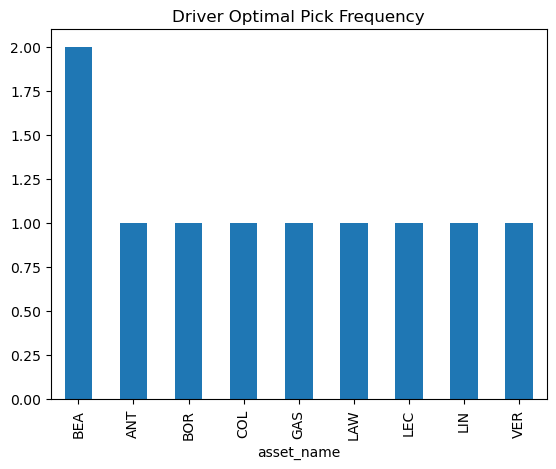

In [352]:
driver_freq = drivers_best_team.groupby("asset_name").size().sort_values(ascending=False)
driver_freq.plot(kind="bar", title="Driver Optimal Pick Frequency")

<Axes: title={'center': 'Constructor Optimal Pick Frequency'}, xlabel='asset_name'>

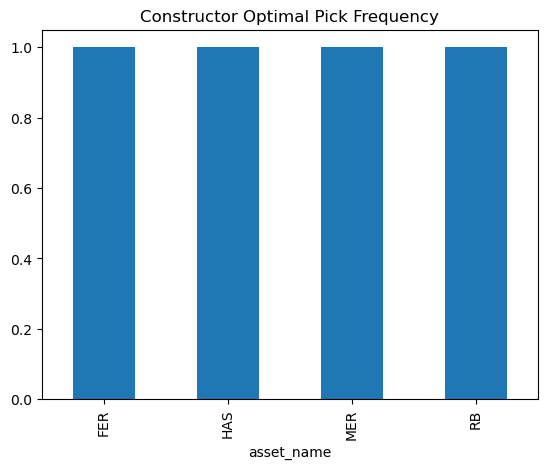

In [353]:
constructor_freq = constructor_best_team.groupby("asset_name").size().sort_values(ascending=False)
constructor_freq.plot(kind="bar", title="Constructor Optimal Pick Frequency")

## Spend Analysis

In [354]:
best_team

,year,race_num,asset_name,asset_type,price,points,team_key,is_drs
0,2026,1,VER,driver,27.7,50.0,RBR,yes
1,2026,1,BEA,driver,7.4,20.0,HAS,no
2,2026,1,LIN,driver,6.2,15.0,RB,no
3,2026,1,BOR,driver,6.4,13.0,AUD,no
4,2026,1,GAS,driver,12.0,11.0,ALP,no
5,2026,1,MER,constructor,29.3,96.0,MER,no
6,2026,1,RB,constructor,6.3,35.0,RB,no
7,2026,2,ANT,driver,23.5,68.0,MER,yes
8,2026,2,LEC,driver,23.1,51.0,FER,no
9,2026,2,LAW,driver,6.3,35.0,RB,no


In [355]:
budget_summary = (
    best_team.groupby(["year", "race_num", "asset_type"])["price"]
    .sum()
    .unstack(fill_value=0)
)

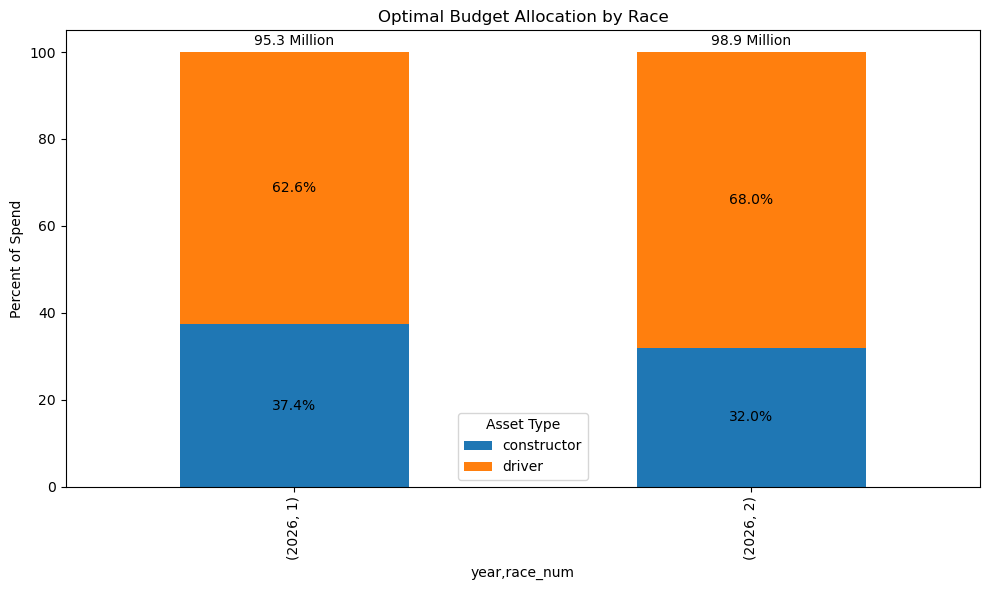

In [361]:
import matplotlib.pyplot as plt
budget_pct = budget_summary.div(budget_summary.sum(axis=1), axis=0) * 100
ax = budget_pct.plot(kind="bar", stacked=True, figsize=(10, 6))
total_spend = budget_summary.sum(axis=1)

for container in ax.containers:
    labels = [
        f"{v:.1f}%" if v > 0 else ""
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type="center")


#total spend for each race
for i, total in enumerate(total_spend):
    ax.text(
        i,                # x position
        101,              # a little above the 100% bar
        f"{total:.1f} Million",   # label text
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylabel("Percent of Spend")
plt.title("Optimal Budget Allocation by Race")
plt.legend(title="Asset Type")
plt.tight_layout()
plt.show()

pricing bucket for drivers and constructors
Premium  ≥ 20
Mid      10 – 19.9
Cheap    < 10


In [357]:
def price_bucket(price):
    if price >= 20:
        return "premium"
    elif price >= 10:
        return "mid"
    else:
        return "cheap"

best_team["price_bucket"] = best_team["price"].apply(price_bucket)
constructor_best_team["price_bucket"] = best_team["price"].apply(price_bucket)
drivers_best_team["price_bucket"] = best_team["price"].apply(price_bucket)

/var/folders/wb/stch18dn2z1gw9s72md26f740000gn/T/ipykernel_6429/2574722309.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  constructor_best_team["price_bucket"] = best_team["price"].apply(price_bucket)
/var/folders/wb/stch18dn2z1gw9s72md26f740000gn/T/ipykernel_6429/2574722309.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drivers_best_team["price_bucket"] = best_team["price"].apply(price_bucket)


In [358]:
constructor_budget_summary_price_bucket = (
    constructor_best_team.groupby(["year", "race_num", "price_bucket"])["price"]
    .sum()
    .unstack(fill_value=0)
)

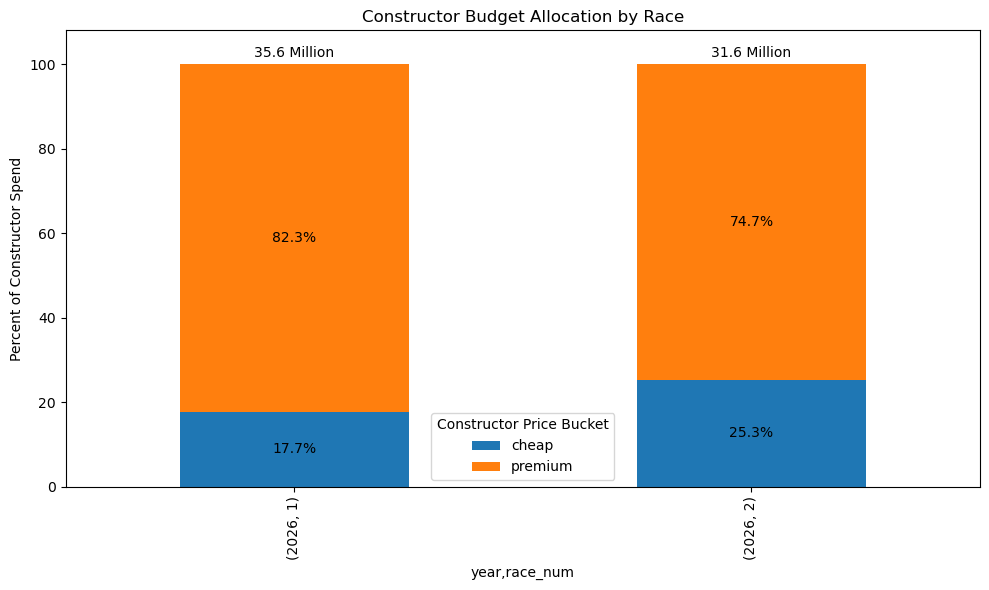

In [362]:
budget_pct = constructor_budget_summary_price_bucket.div(constructor_budget_summary_price_bucket.sum(axis=1), axis=0) * 100
total_spend = constructor_budget_summary_price_bucket.sum(axis=1)

ax = budget_pct.plot(kind="bar", stacked=True, figsize=(10, 6))

for container in ax.containers:
    labels = [
        f"{v:.1f}%" if v > 0 else ""
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type="center")

for i, total in enumerate(total_spend):
    ax.text(
        i,
        101,
        f"{total:.1f} Million",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(0, 108)
plt.ylabel("Percent of Constructor Spend")
plt.title("Constructor Budget Allocation by Race")
plt.legend(title="Constructor Price Bucket")
plt.tight_layout()
plt.show()

In [363]:
driver_budget_summary_price_bucket = (
    drivers_best_team.groupby(["year", "race_num", "price_bucket"])["price"]
    .sum()
    .unstack(fill_value=0)
)

In [370]:
driver_count_summary_price_bucket = (
    best_team[best_team["asset_type"] == "driver"]
    .drop_duplicates(subset=["year","race_num","asset_name"])
    .groupby(["year","race_num","price_bucket"])["asset_name"]
    .count()
    .unstack(fill_value=0)
)

In [372]:
driver_count_summary_price_bucket.sum(axis=1)

year  race_num
2026  1           5
      2           5
dtype: int64

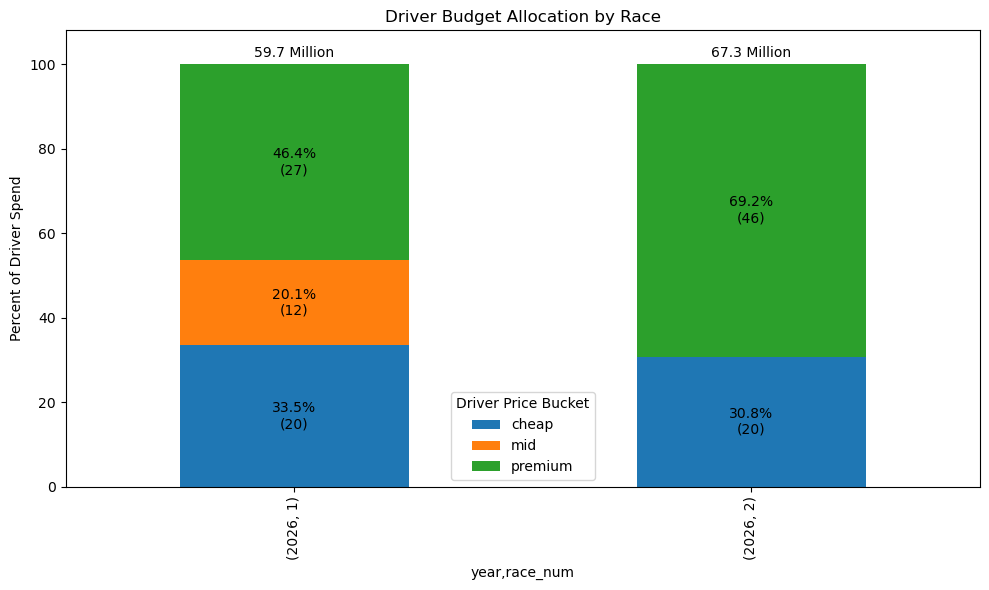

In [373]:
import matplotlib.pyplot as plt

budget_pct = driver_budget_summary_price_bucket.div(driver_budget_summary_price_bucket.sum(axis=1), axis=0) * 100
total_spend = driver_budget_summary_price_bucket.sum(axis=1)

ax = budget_pct.plot(kind="bar", stacked=True, figsize=(10, 6))

for j, container in enumerate(ax.containers):
    bucket = budget_pct.columns[j]

    labels = []
    for i, v in enumerate(container.datavalues):
        count = driver_budget_summary_price_bucket.iloc[i, j]

        if v > 0:
            labels.append(f"{v:.1f}%\n({int(count)})")
        else:
            labels.append("")

    ax.bar_label(container, labels=labels, label_type="center")

for i, total in enumerate(total_spend):
    ax.text(
        i,
        101,
        f"{total:.1f} Million",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(0, 108)
plt.ylabel("Percent of Driver Spend")
plt.title("Driver Budget Allocation by Race")
plt.legend(title="Driver Price Bucket")
plt.tight_layout()
plt.show()